In this notebook, I compare the convergence of first-order Euler step evolution and second-order LPE2 evolution, and show that LPE2 indeed converges to $O(\text dt^2)$ while Euler only does so for $O(\text dt)$. This is to validate my implementation of the procedure.

![plot](images/lpe.png)
![plot](images/lpe-table.png)

The code below runs both, calculates its error with the exact solution for an appropriate choice of function, and shows that Euler has first-order convergence, ie error $\propto \Delta t$, whereas LPE2 has second-order convergence, ie error $\propto \Delta t^2$.

For smaller $\Delta t$, the error no longer decreases at the expected rate. This is likely due to error from discretising the function or floating-point precision.

In [2]:
import utils
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Parameters

In [3]:
n = 9
total_time = 10            # total time that we want all simulations to evolve for

def u(x):
    return np.sin(2*np.pi*2*x) + 0.5*np.sin(2*np.pi*7*x)

nu = 1e-3                 # diffusion coefficient 

# Set Up

In [4]:
N     = 2**n
x     = np.linspace(0, 1, N, endpoint=False)
dx    = x[1] - x[0] 
u0 = u(x)

cfls = [0.2, 0.1, 0.05, 0.025, 0.0125]

errors_e = [] 
errors_l = []
dts = []

for cfl in cfls:
    dt    = utils.delta_t(cfl, dx, nu)
    steps = int(total_time / dt)
    print("steps =", steps)

    L = utils.laplacian(N, dx, "periodic", "dense")

    A1 = utils.time_step(L, 1, dt, nu)
    times_e, us_e, norms_e = utils.evolve_operator(u0, steps, A1, dt)

    A2 = utils.time_step(L, 2, dt, nu)
    times_l, us_l, norms_l = utils.evolve_operator(u0, steps, A2, dt)

    u_exact = la.expm(steps * dt * nu * L) @ u0
    error_e = np.linalg.norm(us_e[-1] - u_exact)
    error_l = np.linalg.norm(us_l[-1] - u_exact)

    errors_e.append(error_e)
    errors_l.append(error_l)
    dts.append(dt)

    print("max imag part LPE2:", np.max(np.abs(us_l[-1].imag)))
    # the maximum imaginary component of the final state should be negligible.


steps = 13107
max imag part LPE2: 1.249000902703301e-16
steps = 26214
max imag part LPE2: 1.9147877727831997e-14
steps = 52428
max imag part LPE2: 7.632783294297951e-17
steps = 104857
max imag part LPE2: 6.938893903907228e-17
steps = 209715
max imag part LPE2: 3.570060913560269e-15


Observed convergence orders:
  interval 0: Euler = 1.000, LPE2 = 1.998
  interval 1: Euler = 1.000, LPE2 = 2.031
  interval 2: Euler = 1.000, LPE2 = 2.052
  interval 3: Euler = 1.000, LPE2 = 0.804


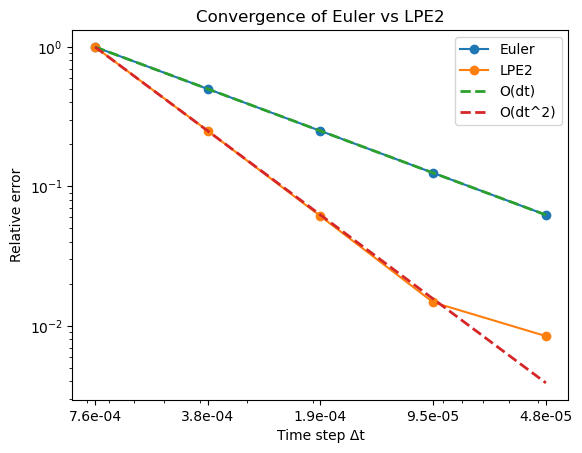

In [5]:
dts = np.array(dts)
errors_e = np.array(errors_e)
errors_l = np.array(errors_l)

c1 = errors_e[0] / dts[0]
c2 = errors_l[0] / (dts[0]**2)

print("Observed convergence orders:")
for i in range(len(dts) - 1):
    p_euler = np.log(errors_e[i] / errors_e[i+1]) / np.log(dts[i] / dts[i+1])
    p_lpe2  = np.log(errors_l[i]  / errors_l[i+1])  / np.log(dts[i] / dts[i+1])
    print(f"  interval {i}: Euler = {p_euler:.3f}, LPE2 = {p_lpe2:.3f}")


errors_e_norm = errors_e / errors_e[0]
errors_l_norm = errors_l / errors_l[0]

plt.loglog(dts, errors_e_norm, 'o-', label='Euler')
plt.loglog(dts, errors_l_norm, 'o-', label='LPE2')

plt.loglog(dts, dts / dts[0], '--', linewidth=2, label='O(dt)')
plt.loglog(dts, (dts / dts[0])**2, '--', linewidth=2, label='O(dt^2)')

plt.gca().invert_xaxis()

plt.xlabel("Time step Δt")
plt.xticks(dts, [f"{dt:.1e}" for dt in dts])
plt.ylabel("Relative error")
plt.title("Convergence of Euler vs LPE2")
plt.legend()
plt.show()

This validates the implementation of first- and second-order time evolution.